<a href="https://colab.research.google.com/github/KaveenKK/YouTube-Trending-Video-Analysis/blob/main/youtube_video_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YouTube Trending Video Analysis (US)

This notebook explores the factors that contribute to videos trending on YouTube in the United States. We will examine categories, engagement metrics, and temporal patterns.

# YouTube Trending Video Analysis (US Dataset)

## Project Overview
This project performs an exploratory data analysis (EDA) on the YouTube Trending Videos dataset to uncover patterns in viral content. By analyzing engagement metrics, categories, and temporal trends, we aim to understand what makes a video trend in the United States.

### Key Objectives:
1.  **Category Popularity:** Identify which content categories (e.g., Entertainment, Music) dominate the trending list.
2.  **Engagement Analysis:** Explore the relationship between views, likes, dislikes, and comment counts to measure audience interaction.
3.  **Efficiency Ratios:** Analyze like-to-dislike and comment-to-view ratios to identify highly positive or controversial content.
4.  **Temporal Trends:** Observe how trending volume and engagement fluctuate over time to identify peak periods of activity.

In [2]:
import kagglehub
path = kagglehub.dataset_download("datasnaek/youtube-new")

Using Colab cache for faster access to the 'youtube-new' dataset.


### 1. Data Loading and Initial Inspection
We start by downloading the dataset using `kagglehub` and listing the available files to identify the US-specific data.

First, let's explore the downloaded dataset by listing the files in the directory. This will help us identify which files contain the data we want to analyze.

In [3]:
import os

# List the files in the downloaded dataset directory
print(os.listdir(path))

['GBvideos.csv', 'MXvideos.csv', 'KRvideos.csv', 'MX_category_id.json', 'GB_category_id.json', 'US_category_id.json', 'IN_category_id.json', 'DEvideos.csv', 'KR_category_id.json', 'RU_category_id.json', 'FRvideos.csv', 'USvideos.csv', 'INvideos.csv', 'RUvideos.csv', 'CA_category_id.json', 'DE_category_id.json', 'JP_category_id.json', 'JPvideos.csv', 'FR_category_id.json', 'CAvideos.csv']


From the list of files, we can see several CSV files like `CAvideos.csv`, `USvideos.csv`, `INvideos.csv`, etc., which likely contain the trending video data for different countries. There are also corresponding JSON files that probably contain category ID mappings.

Let's start by loading one of the CSV files, for example, `USvideos.csv`, into a pandas DataFrame to inspect its structure and content.

In [4]:
import pandas as pd

# Construct the full path to the USvideos.csv file
us_videos_csv_path = os.path.join(path, 'USvideos.csv')

# Load the CSV file into a pandas DataFrame
df_us = pd.read_csv(us_videos_csv_path)

# Display the first 5 rows of the DataFrame
print('First 5 rows of USvideos.csv:')
display(df_us.head())

First 5 rows of USvideos.csv:


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


### 2. Data Cleaning
To prepare the data for analysis, we convert date strings into datetime objects, extract time-based features, and handle missing descriptions.

Now that we've loaded the `USvideos.csv` into a DataFrame, let's get a comprehensive overview of its structure, data types, and summary statistics. This initial exploration is crucial for understanding the dataset's characteristics and identifying any potential issues like missing values or incorrect data types that might need cleaning or preprocessing.

In [5]:
# Display concise summary of the DataFrame, including data types and non-null values
print('DataFrame Info:')
df_us.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null

The `info()` output gives us a good sense of the columns, their data types, and whether they contain missing values. For numerical columns, it's also helpful to see statistical summaries like mean, min, max, and quartiles.

In [6]:
# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics:')
display(df_us.describe())


Descriptive Statistics:


,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


## Data Cleaning and Preprocessing

Based on the `info()` and `describe()` outputs, we need to perform some data cleaning and preprocessing steps:

1.  **Convert `trending_date` to datetime:** It's currently an object, but it contains date information. We need to parse it correctly.
2.  **Convert `publish_time` to datetime:** This column also contains date and time information as an object and should be converted.
3.  **Handle missing values:** The `description` column has some missing values that we might need to address (e.g., fill with an empty string or 'No Description').
4.  **Feature Engineering:** Extract potentially useful features like the day of the week for trending, or the hour of publication.

In [7]:
# Convert 'trending_date' to datetime format
# The format seems to be 'YY.DD.MM' based on the head, but pandas is smart enough to infer for common formats
df_us['trending_date'] = pd.to_datetime(df_us['trending_date'], format='%y.%d.%m')

# Convert 'publish_time' to datetime format
df_us['publish_time'] = pd.to_datetime(df_us['publish_time'])

# Extract 'publish_date' and 'publish_hour' from 'publish_time'
df_us['publish_date'] = df_us['publish_time'].dt.date
df_us['publish_hour'] = df_us['publish_time'].dt.hour

# Fill missing 'description' values with an empty string
df_us['description'] = df_us['description'].fillna('No Description')

# Verify data types after conversion and changes
print('DataFrame Info after type conversions and missing value handling:')
df_us.info()

# Display the first few rows with new columns and converted types
print('\nFirst 5 rows of DataFrame after preprocessing:')
display(df_us.head())

DataFrame Info after type conversions and missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,publish_date,publish_hour
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,2017-11-13,17
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",2017-11-13,7
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,2017-11-12,19
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,2017-11-13,11
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,2017-11-12,18


## Exploratory Data Analysis (EDA)

Let's start our EDA by understanding the distribution of video categories. This will give us insights into which types of content are most popular among trending videos.

Top 10 Most Frequent Categories (by ID):


,category_id,count
0,24,9964
1,10,6472
2,26,4146
3,23,3457
4,22,3210
5,25,2487
6,28,2401
7,1,2345
8,17,2174
9,27,1656


/tmp/ipykernel_17995/2957641034.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category_id', y='count', data=category_counts.head(10), palette='viridis')


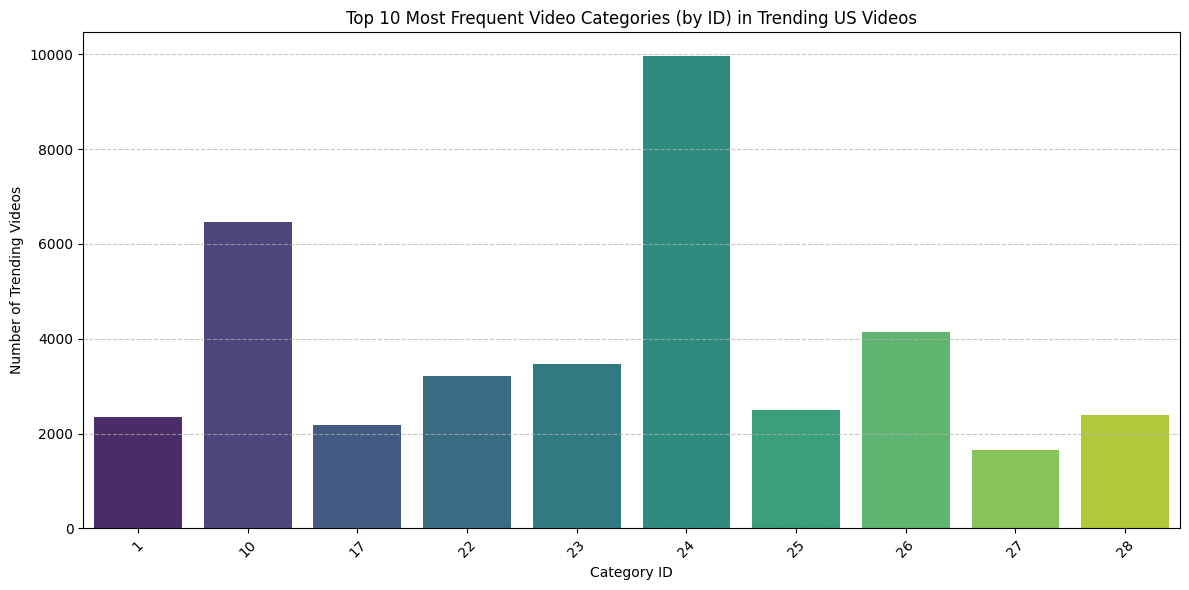

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each category_id
category_counts = df_us['category_id'].value_counts().reset_index()
category_counts.columns = ['category_id', 'count']

# Display the top 10 most frequent categories
print('Top 10 Most Frequent Categories (by ID):')
display(category_counts.head(10))

# Visualize the distribution of the top 10 categories
plt.figure(figsize=(12, 6))
sns.barplot(x='category_id', y='count', data=category_counts.head(10), palette='viridis')
plt.title('Top 10 Most Frequent Video Categories (by ID) in Trending US Videos')
plt.xlabel('Category ID')
plt.ylabel('Number of Trending Videos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

To make the category analysis more meaningful, we should load the category names from the `US_category_id.json` file. This will allow us to see human-readable category names instead of just IDs.


Top 10 Most Frequent Categories (by Name):


,category_name,count
0,Entertainment,9964
1,Music,6472
2,Howto & Style,4146
3,Comedy,3457
4,People & Blogs,3210
5,News & Politics,2487
6,Science & Technology,2401
7,Film & Animation,2345
8,Sports,2174
9,Education,1656


/tmp/ipykernel_17995/3631210083.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category_name', y='count', data=category_counts_named.head(10), palette='viridis')


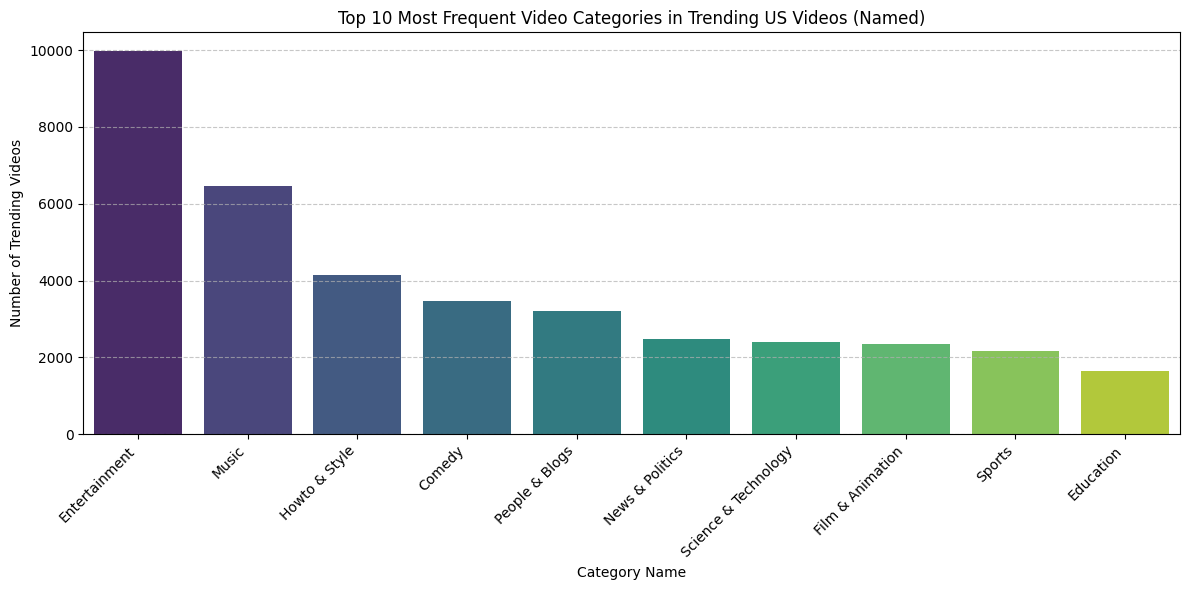

In [9]:
import json

# Construct the full path to the US_category_id.json file
us_category_json_path = os.path.join(path, 'US_category_id.json')

# Load the JSON file
with open(us_category_json_path, 'r') as f:
    category_data = json.load(f)

# Create a dictionary mapping category_id to category_name
category_id_to_name = {int(item['id']): item['snippet']['title'] for item in category_data['items']}

# Map the category_id in the DataFrame to category names
df_us['category_name'] = df_us['category_id'].map(category_id_to_name)

# Re-calculate category counts with names
category_counts_named = df_us['category_name'].value_counts().reset_index()
category_counts_named.columns = ['category_name', 'count']

print('\nTop 10 Most Frequent Categories (by Name):')
display(category_counts_named.head(10))

# Visualize the distribution of the top 10 named categories
plt.figure(figsize=(12, 6))
sns.barplot(x='category_name', y='count', data=category_counts_named.head(10), palette='viridis')
plt.title('Top 10 Most Frequent Video Categories in Trending US Videos (Named)')
plt.xlabel('Category Name')
plt.ylabel('Number of Trending Videos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Category & Engagement Analysis
Here we visualize which categories trend most often and analyze the distribution of user interactions like views, likes, and comments.

### Distribution of Engagement Metrics

Let's visualize the distributions of views, likes, dislikes, and comment counts to understand the spread and identify potential outliers or common engagement levels.

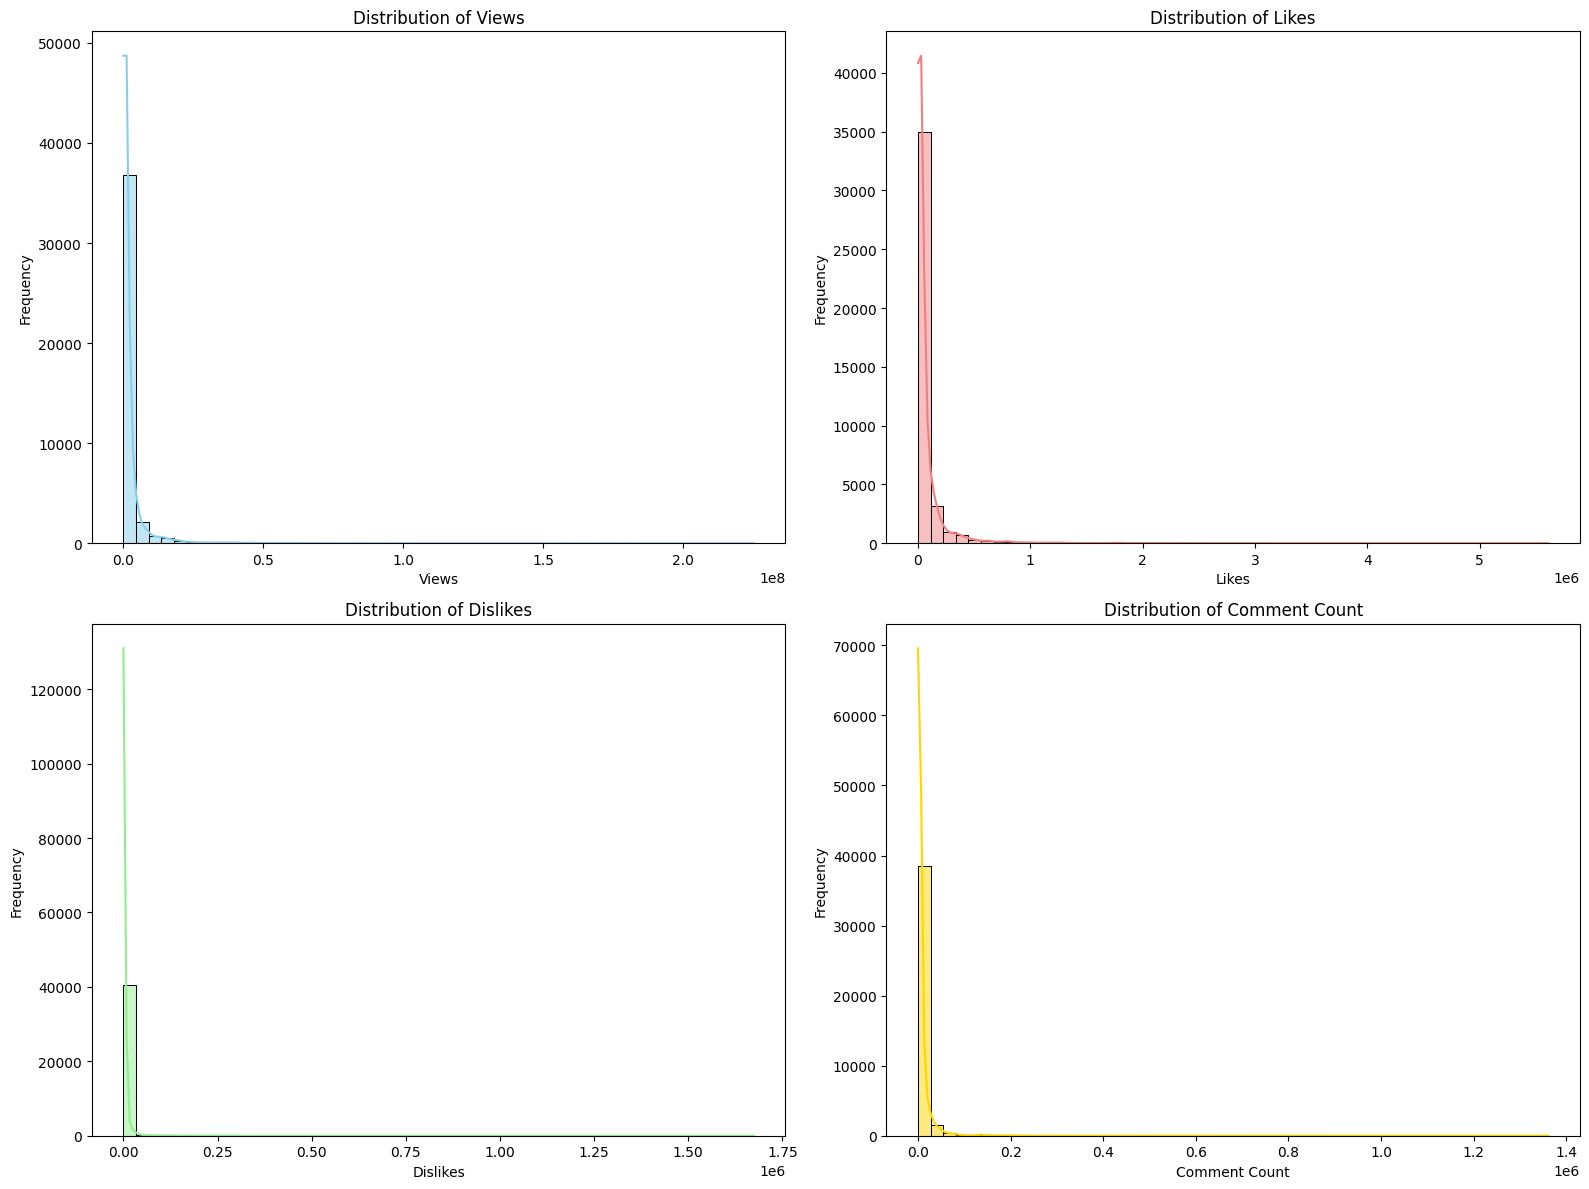

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df_us['views'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Views')
axes[0, 0].set_xlabel('Views')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df_us['likes'], bins=50, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribution of Likes')
axes[0, 1].set_xlabel('Likes')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(df_us['dislikes'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Dislikes')
axes[1, 0].set_xlabel('Dislikes')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df_us['comment_count'], bins=50, kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Comment Count')
axes[1, 1].set_xlabel('Comment Count')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

These distributions show a strong right skew, meaning most videos have lower engagement, while a few videos have extremely high views, likes, dislikes, and comments. This is typical for viral content platforms like YouTube.

Let's calculate and visualize some engagement ratios to get a more normalized view of how videos perform, specifically the like-to-dislike ratio and the comment-to-view ratio. This can help identify videos that, regardless of absolute numbers, are particularly well-received or controversial.

Descriptive Statistics for Engagement Ratios:


,like_dislike_ratio,comment_view_ratio
count,4.094900e+04,40949.000000
mean,1.124028e+05,0.004453
std,2.674685e+06,0.005736
min,0.000000e+00,0.000000
25%,1.316716e+01,0.001607
50%,2.915562e+01,0.002961
75%,5.690909e+01,0.005214
max,2.600000e+08,0.117643


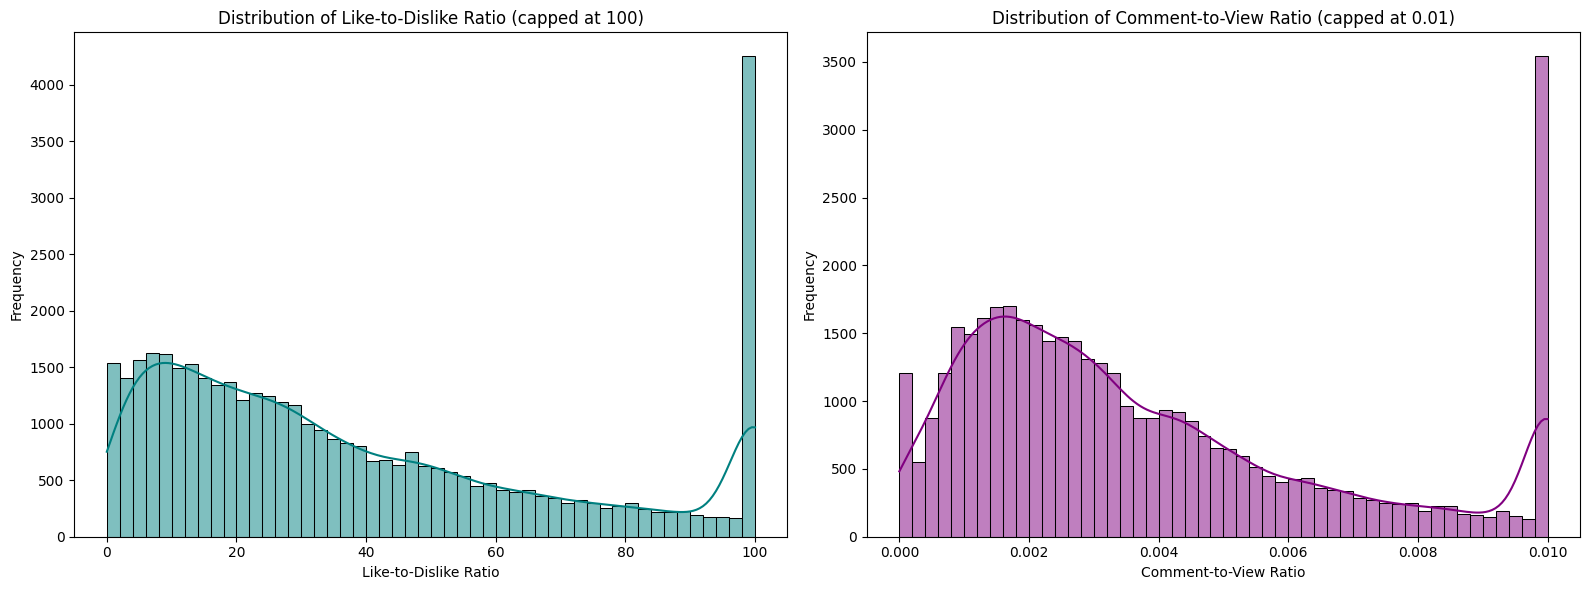

In [11]:
# Calculate engagement ratios
# Add a small epsilon to avoid division by zero for videos with 0 views/dislikes
df_us['like_dislike_ratio'] = df_us['likes'] / (df_us['dislikes'] + 1e-6)
df_us['comment_view_ratio'] = df_us['comment_count'] / (df_us['views'] + 1e-6)

# Display descriptive statistics for new ratios
print('Descriptive Statistics for Engagement Ratios:')
display(df_us[['like_dislike_ratio', 'comment_view_ratio']].describe())

# Visualize the distributions of engagement ratios
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_us['like_dislike_ratio'].apply(lambda x: min(x, 100)), bins=50, kde=True, ax=axes[0], color='teal') # Capping for better visualization
axes[0].set_title('Distribution of Like-to-Dislike Ratio (capped at 100)')
axes[0].set_xlabel('Like-to-Dislike Ratio')
axes[0].set_ylabel('Frequency')

sns.histplot(df_us['comment_view_ratio'].apply(lambda x: min(x, 0.01)), bins=50, kde=True, ax=axes[1], color='purple') # Capping for better visualization
axes[1].set_title('Distribution of Comment-to-View Ratio (capped at 0.01)')
axes[1].set_xlabel('Comment-to-View Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Relationships Between Engagement Metrics

Let's investigate the correlations between views, likes, dislikes, and comment counts. A correlation matrix and scatter plots can reveal if there are strong positive or negative relationships between these metrics.

Correlation Matrix of Engagement Metrics:


,views,likes,dislikes,comment_count
views,1.000000,0.849177,0.472213,0.617621
likes,0.849177,1.000000,0.447186,0.803057
dislikes,0.472213,0.447186,1.000000,0.700184
comment_count,0.617621,0.803057,0.700184,1.000000


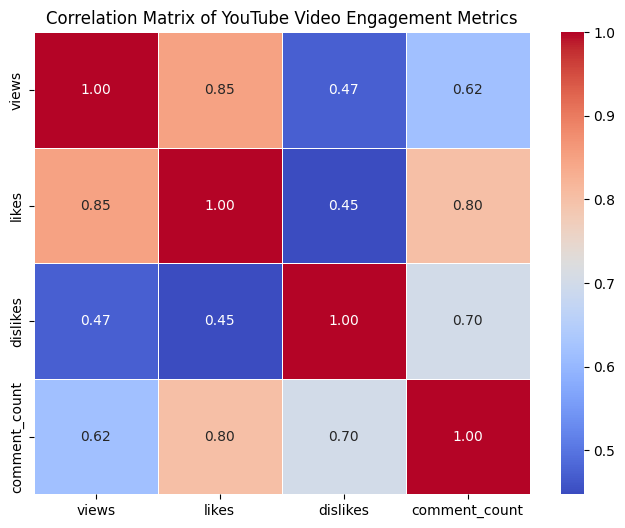

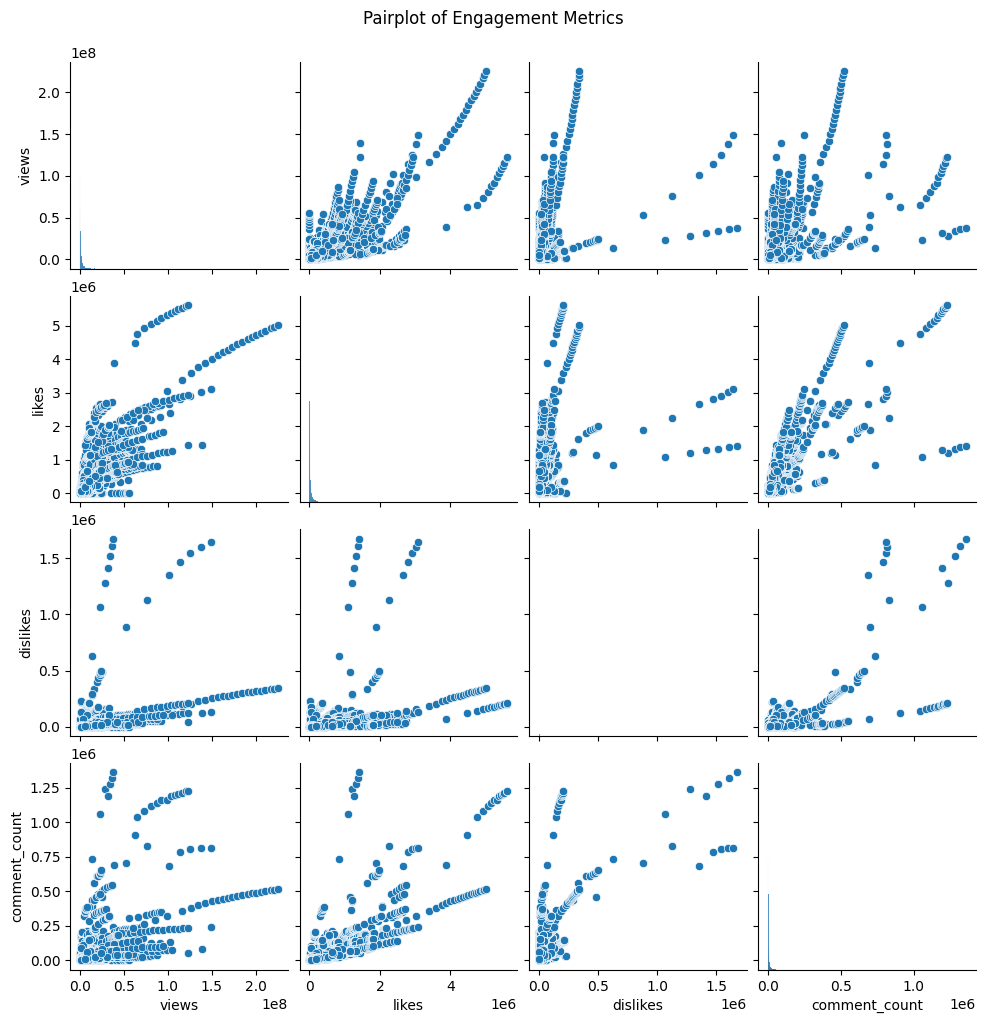

In [12]:
# Select relevant numerical columns for correlation analysis
engagement_cols = ['views', 'likes', 'dislikes', 'comment_count']

# Calculate the correlation matrix
correlation_matrix = df_us[engagement_cols].corr()

print('Correlation Matrix of Engagement Metrics:')
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of YouTube Video Engagement Metrics')
plt.show()

# Pairplot to visualize relationships between numerical features
sns.pairplot(df_us[engagement_cols])
plt.suptitle('Pairplot of Engagement Metrics', y=1.02) # Adjust title position
plt.show()

### Time-Based Trends

Since we have `trending_date` and `publish_time`, let's analyze how various metrics change over time. This can help identify any daily, weekly, or overall trends in how videos become and stay popular.

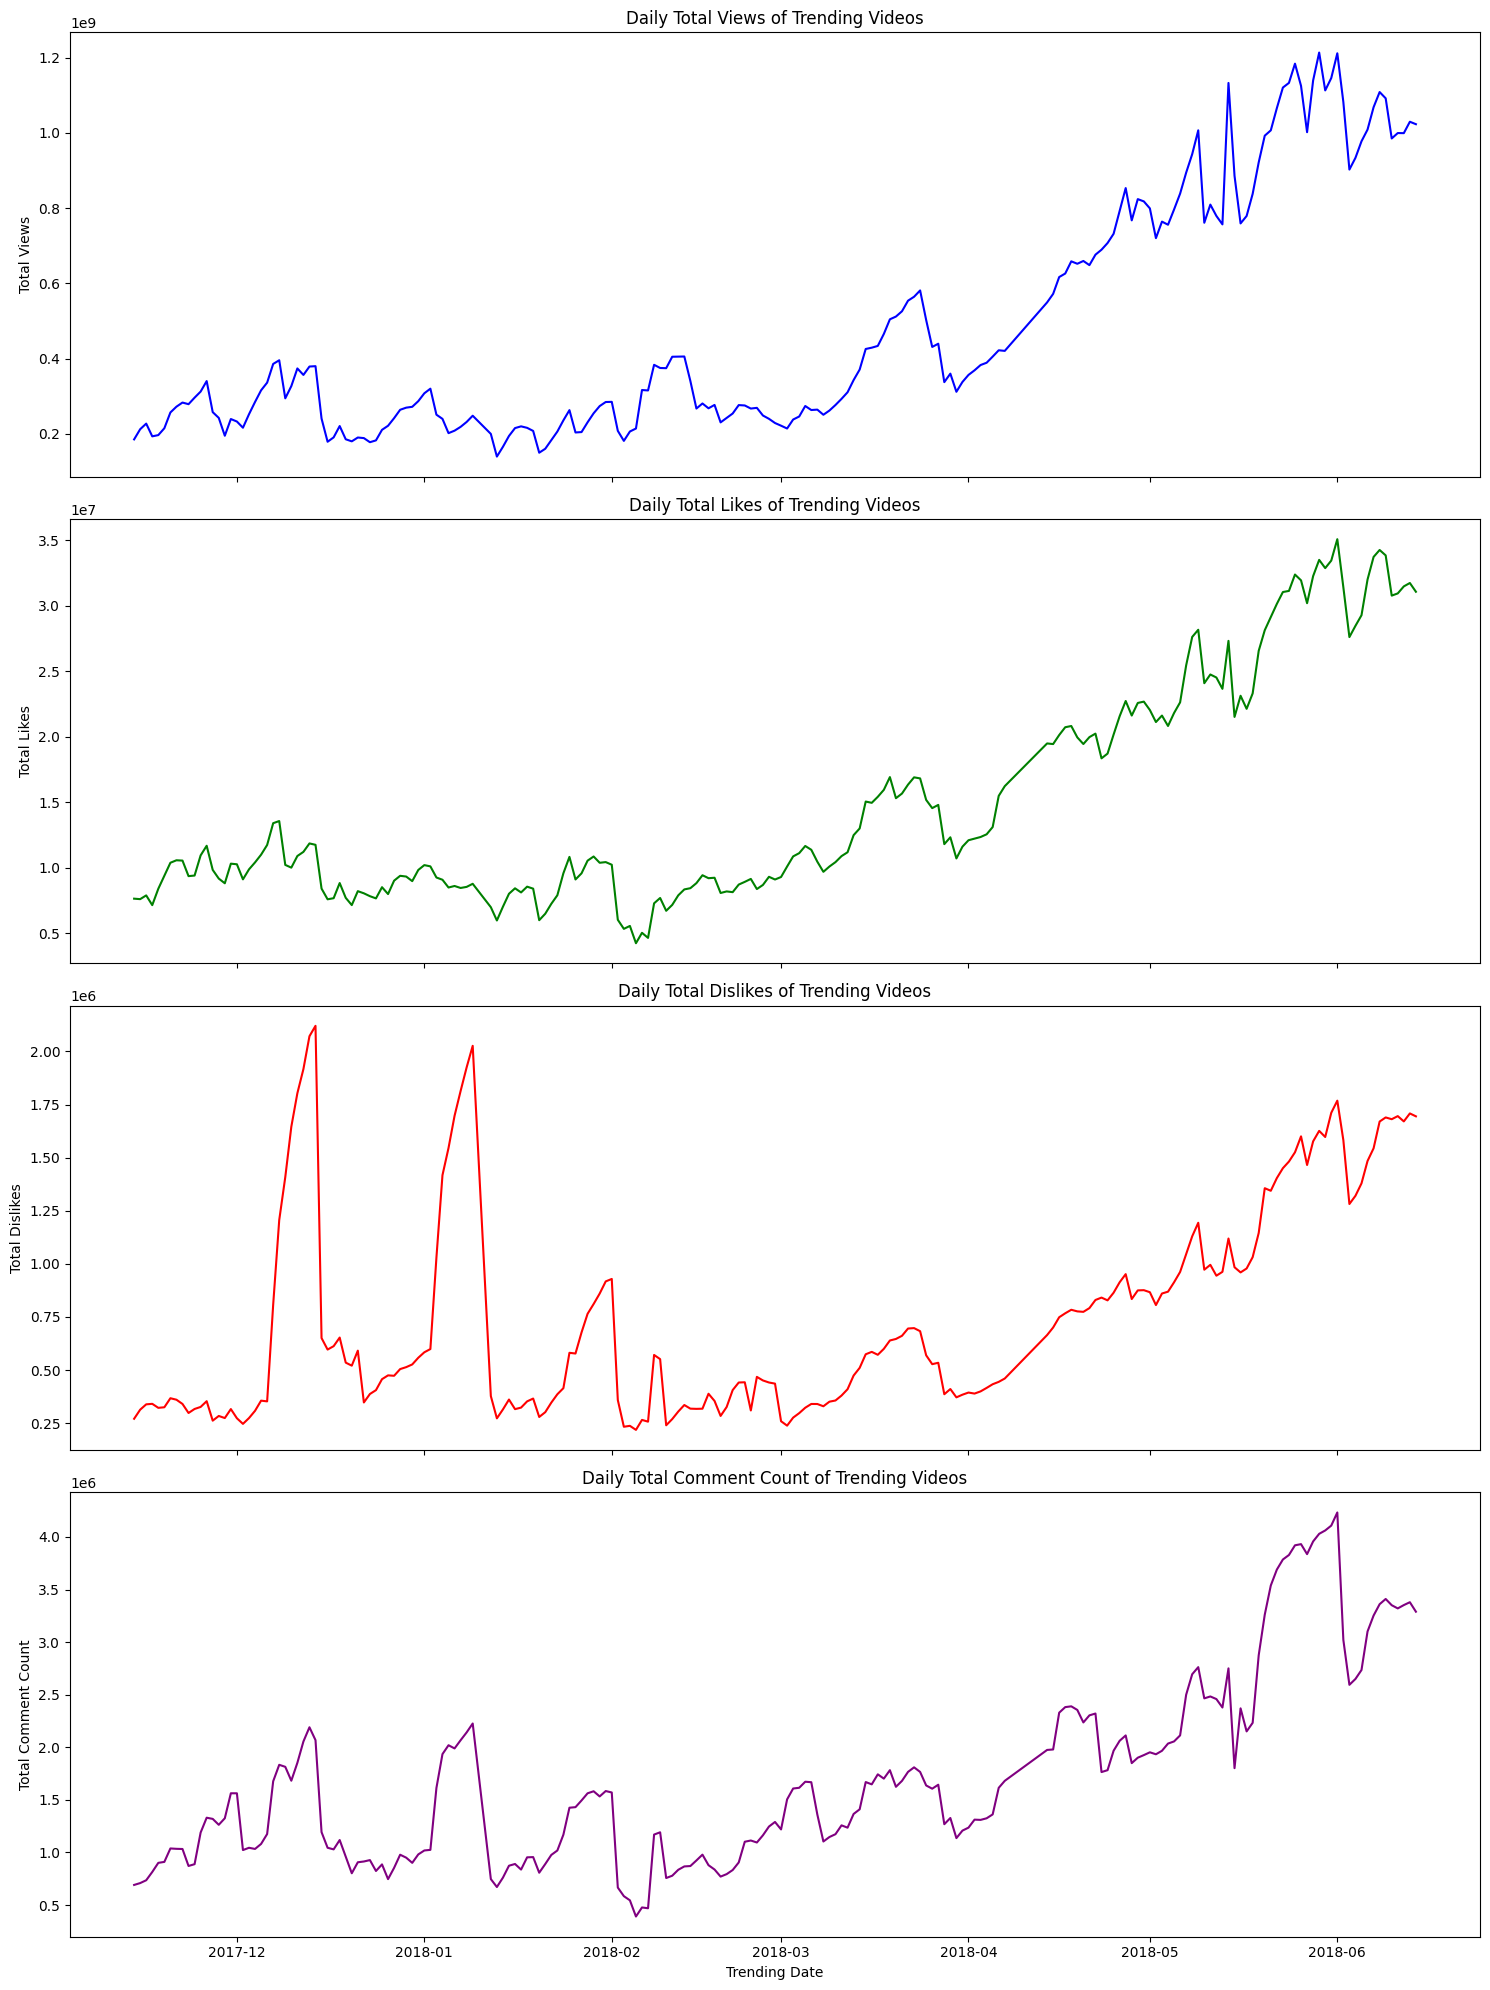

In [13]:
# Aggregate data by trending_date for time-series analysis
daily_trends = df_us.groupby('trending_date')[['views', 'likes', 'dislikes', 'comment_count']].sum().reset_index()

# Plotting daily trends
fig, axes = plt.subplots(4, 1, figsize=(15, 20), sharex=True)

sns.lineplot(x='trending_date', y='views', data=daily_trends, ax=axes[0], color='blue')
axes[0].set_title('Daily Total Views of Trending Videos')
axes[0].set_ylabel('Total Views')

sns.lineplot(x='trending_date', y='likes', data=daily_trends, ax=axes[1], color='green')
axes[1].set_title('Daily Total Likes of Trending Videos')
axes[1].set_ylabel('Total Likes')

sns.lineplot(x='trending_date', y='dislikes', data=daily_trends, ax=axes[2], color='red')
axes[2].set_title('Daily Total Dislikes of Trending Videos')
axes[2].set_ylabel('Total Dislikes')

sns.lineplot(x='trending_date', y='comment_count', data=daily_trends, ax=axes[3], color='purple')
axes[3].set_title('Daily Total Comment Count of Trending Videos')
axes[3].set_xlabel('Trending Date')
axes[3].set_ylabel('Total Comment Count')

plt.tight_layout()
plt.show()

## Summary and Conclusion

Based on the analysis above, we can observe several key trends in the US YouTube market:
- **Dominant Categories:** 'Entertainment' and 'Music' are consistently the most represented categories in the trending list.
- **Engagement Correlation:** There is a strong positive correlation between views and likes, suggesting that highly viewed videos generally maintain high approval ratings.
- **Temporal Spikes:** The time-series plots reveal specific dates with massive surges in engagement, likely corresponding to major real-world events or viral releases.
- **Audience Interaction:** The like-to-dislike ratio remains high for most trending content, indicating that 'Trending' videos are generally well-received by the community.

# ============================================================
# SECTION 4: FEATURE ENGINEERING
# ============================================================

In [14]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# --- Deduplicate: keep last appearance of each video (max engagement snapshot) ---
df_ml = df_us.sort_values('trending_date').drop_duplicates(subset='video_id', keep='last').copy()
df_ml = df_ml[df_ml['views'] > 0].reset_index(drop=True)

# --- Title features ---
df_ml['title_length']     = df_ml['title'].str.len()
df_ml['title_word_count'] = df_ml['title'].str.split().str.len()
df_ml['title_has_caps']   = df_ml['title'].str.contains(r'[A-Z]{2,}').astype(int)
df_ml['title_has_number'] = df_ml['title'].str.contains(r'\d').astype(int)
df_ml['title_has_excl']   = df_ml['title'].str.contains('!').astype(int)
df_ml['title_has_question']= df_ml['title'].str.contains(r'\?').astype(int)

# --- Tag features ---
df_ml['tag_count'] = df_ml['tags'].apply(
    lambda x: 0 if x == '[none]' else len(str(x).split('|'))
)

# --- Time features ---
df_ml['publish_hour']    = pd.to_datetime(df_ml['publish_time']).dt.hour
df_ml['publish_dayofweek'] = pd.to_datetime(df_ml['publish_time']).dt.dayofweek
df_ml['publish_month']   = pd.to_datetime(df_ml['publish_time']).dt.month
df_ml['is_weekend']      = (df_ml['publish_dayofweek'] >= 5).astype(int)

# Days between publish and trending
df_ml['days_to_trend'] = (
    df_ml['trending_date'] - pd.to_datetime(df_ml['publish_time']).dt.tz_localize(None)
).dt.days.clip(lower=0)

# --- Category encoding ---
le = LabelEncoder()
df_ml['category_encoded'] = le.fit_transform(df_ml['category_name'].fillna('Unknown'))

# --- Log-transform target (views is very skewed) ---
df_ml['log_views'] = np.log1p(df_ml['views'])

# --- Boolean features ---
df_ml['comments_disabled_int'] = df_ml['comments_disabled'].astype(int)
df_ml['ratings_disabled_int']  = df_ml['ratings_disabled'].astype(int)

print(f"Dataset for ML: {df_ml.shape[0]} unique videos")
print("\nNew features created:")
new_features = [
    'title_length','title_word_count','title_has_caps','title_has_number',
    'title_has_excl','title_has_question','tag_count','publish_hour',
    'publish_dayofweek','publish_month','is_weekend','days_to_trend',
    'category_encoded','log_views','comments_disabled_int','ratings_disabled_int'
]
print(df_ml[new_features].describe().round(2))

Dataset for ML: 6351 unique videos

New features created:
       title_length  title_word_count  title_has_caps  title_has_number  \
count       6351.00           6351.00         6351.00           6351.00   
mean          49.82              8.72            0.37              0.26   
std           19.72              3.53            0.48              0.44   
min            3.00              1.00            0.00              0.00   
25%           35.50              6.00            0.00              0.00   
50%           48.00              8.00            0.00              0.00   
75%           62.00             11.00            1.00              1.00   
max          100.00             23.00            1.00              1.00   

       title_has_excl  title_has_question  tag_count  publish_hour  \
count         6351.00             6351.00    6351.00       6351.00   
mean             0.11                0.06      19.92         13.52   
std              0.31                0.23      12.23    

# ============================================================
# SECTION 5: REGRESSION — PREDICT LOG(VIEWS)
# ============================================================

Ridge Regression     | CV RMSE: 1.7808 ± 0.0477 | Test R²: 0.0638
Random Forest        | CV RMSE: 1.4602 ± 0.0288 | Test R²: 0.3529
XGBoost              | CV RMSE: 1.4308 ± 0.0304 | Test R²: 0.3799


,Model,CV RMSE (mean),CV RMSE (std),Test RMSE,Test R²
0,Ridge Regression,1.7808,0.0477,1.8192,0.0638
1,Random Forest,1.4602,0.0288,1.5125,0.3529
2,XGBoost,1.4308,0.0304,1.4806,0.3799


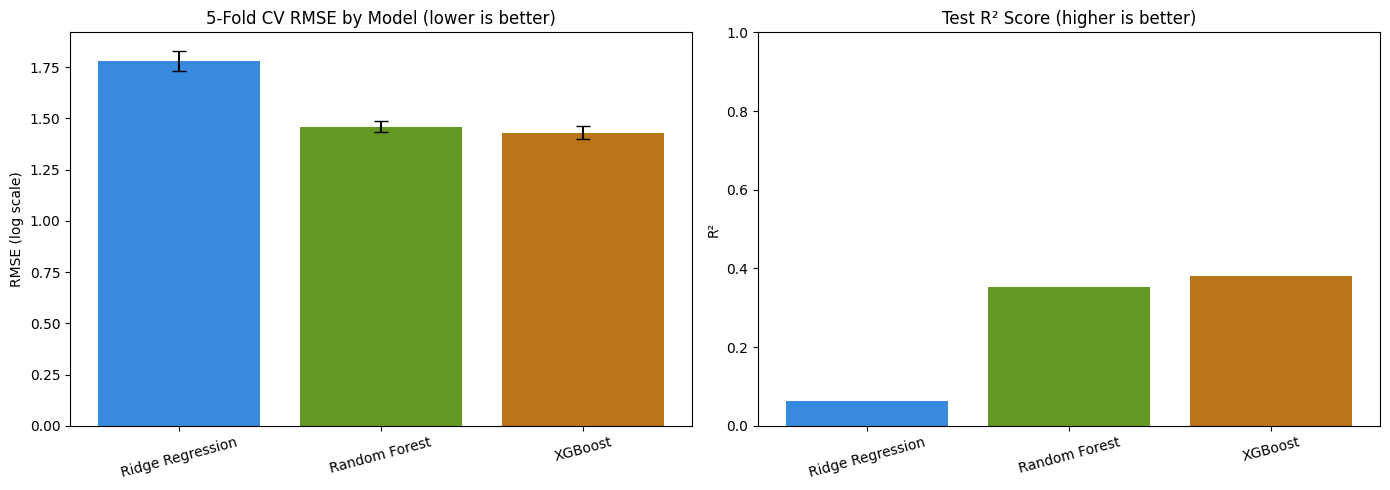

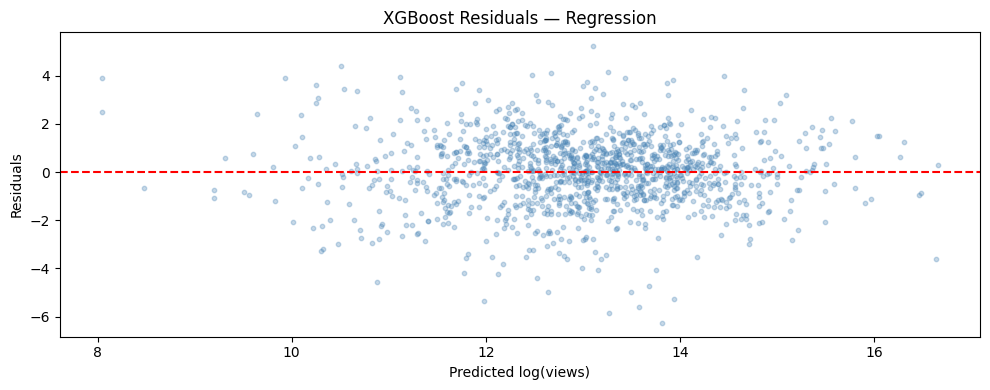

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# --- Define features ---
REG_FEATURES = [
    'title_length', 'title_word_count', 'title_has_caps', 'title_has_number',
    'title_has_excl', 'title_has_question', 'tag_count',
    'publish_hour', 'publish_dayofweek', 'publish_month', 'is_weekend',
    'days_to_trend', 'category_encoded',
    'comments_disabled_int', 'ratings_disabled_int'
]
TARGET_REG = 'log_views'

X_reg = df_ml[REG_FEATURES]
y_reg = df_ml[TARGET_REG]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --- Models ---
models_reg = {
    'Ridge Regression': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost':          xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, verbosity=0),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
reg_results = []

for name, model in models_reg.items():
    cv_rmse = -cross_val_score(model, X_train_r, y_train_r,
                                scoring='neg_root_mean_squared_error', cv=kfold)
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    test_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    test_r2   = r2_score(y_test_r, y_pred)
    reg_results.append({
        'Model': name,
        'CV RMSE (mean)': cv_rmse.mean().round(4),
        'CV RMSE (std)':  cv_rmse.std().round(4),
        'Test RMSE':      round(test_rmse, 4),
        'Test R²':        round(test_r2, 4)
    })
    print(f"{name:20s} | CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} | Test R²: {test_r2:.4f}")

reg_results_df = pd.DataFrame(reg_results)
display(reg_results_df)

# --- Visualize model comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(reg_results_df['Model'], reg_results_df['CV RMSE (mean)'],
            yerr=reg_results_df['CV RMSE (std)'], capsize=5,
            color=['#378ADD', '#639922', '#BA7517'])
axes[0].set_title('5-Fold CV RMSE by Model (lower is better)')
axes[0].set_ylabel('RMSE (log scale)')
axes[0].set_xticklabels(reg_results_df['Model'], rotation=15)

axes[1].bar(reg_results_df['Model'], reg_results_df['Test R²'],
            color=['#378ADD', '#639922', '#BA7517'])
axes[1].set_title('Test R² Score (higher is better)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(reg_results_df['Model'], rotation=15)

plt.tight_layout()
plt.show()

# --- Best model: residual plot ---
best_reg = models_reg['XGBoost']
y_pred_best = best_reg.predict(X_test_r)
residuals = y_test_r.values - y_pred_best

plt.figure(figsize=(10, 4))
plt.scatter(y_pred_best, residuals, alpha=0.3, s=10, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(views)')
plt.ylabel('Residuals')
plt.title('XGBoost Residuals — Regression')
plt.tight_layout()
plt.show()

# ============================================================
# SECTION 6: CLASSIFICATION — VIRAL vs NON-VIRAL
# ============================================================

Viral threshold: 1,473,582 views
Viral: 1588 | Non-viral: 4763

Running RandomizedSearchCV on Random Forest...
Best params: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.7734

=== Random Forest (tuned) ===
ROC-AUC: 0.7843
              precision    recall  f1-score   support

   Non-viral       0.83      0.87      0.85       953
       Viral       0.54      0.45      0.49       318

    accuracy                           0.77      1271
   macro avg       0.68      0.66      0.67      1271
weighted avg       0.76      0.77      0.76      1271


=== XGBoost ===
ROC-AUC: 0.8078
              precision    recall  f1-score   support

   Non-viral       0.82      0.91      0.86       953
       Viral       0.60      0.38      0.47       318

    accuracy                           0.78      1271
   macro avg       0.71      0.65      0.66      1271
weighted avg       0.76      0.78      0.76      1271



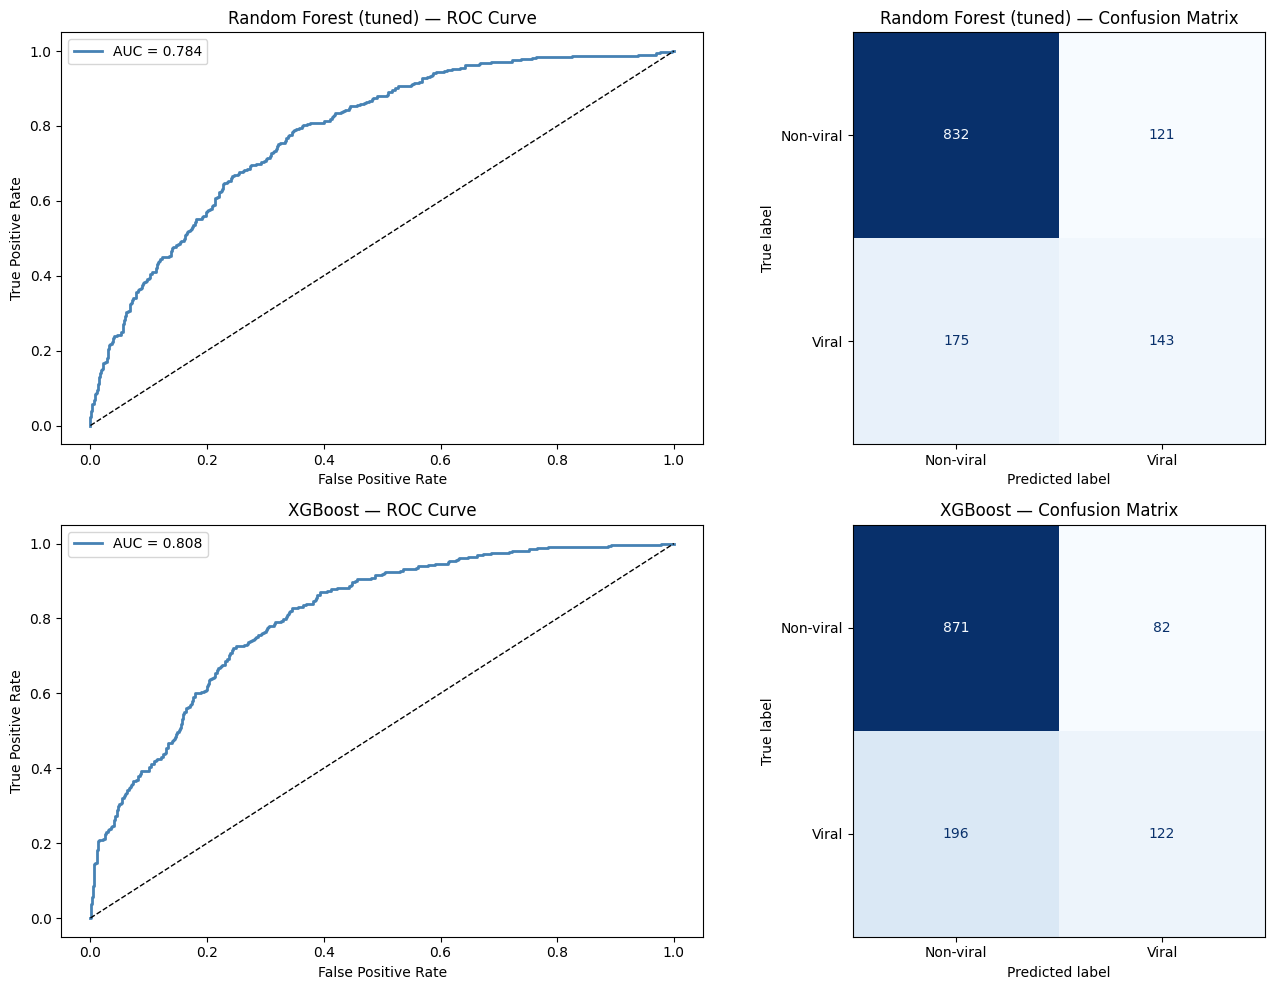

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# --- Binary label: top 25% views = "viral" ---
threshold = df_ml['views'].quantile(0.75)
df_ml['is_viral'] = (df_ml['views'] >= threshold).astype(int)
print(f"Viral threshold: {threshold:,.0f} views")
print(f"Viral: {df_ml['is_viral'].sum()} | Non-viral: {(df_ml['is_viral']==0).sum()}")

CLF_FEATURES = REG_FEATURES  # same feature set
TARGET_CLF = 'is_viral'

X_clf = df_ml[CLF_FEATURES]
y_clf = df_ml[TARGET_CLF]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# --- Hyperparameter tuning with RandomizedSearchCV ---
print("\nRunning RandomizedSearchCV on Random Forest...")
param_dist = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features':  ['sqrt', 'log2'],
    'class_weight':  ['balanced', None]
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_cv = RandomizedSearchCV(
    rf_base, param_dist, n_iter=20, scoring='roc_auc',
    cv=skf, random_state=42, n_jobs=-1, verbose=0
)
rs_cv.fit(X_train_c, y_train_c)
print(f"Best params: {rs_cv.best_params_}")
print(f"Best CV ROC-AUC: {rs_cv.best_score_:.4f}")

best_rf = rs_cv.best_estimator_

# --- XGBoost classifier ---
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='logloss', random_state=42, verbosity=0
)
xgb_clf.fit(X_train_c, y_train_c)

# --- Evaluate both ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (name, model) in enumerate([('Random Forest (tuned)', best_rf), ('XGBoost', xgb_clf)]):
    y_pred_c  = model.predict(X_test_c)
    y_prob_c  = model.predict_proba(X_test_c)[:, 1]
    auc       = roc_auc_score(y_test_c, y_prob_c)
    fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)

    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test_c, y_pred_c, target_names=['Non-viral', 'Viral']))

    # ROC curve
    axes[i][0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue', lw=2)
    axes[i][0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i][0].set_title(f'{name} — ROC Curve')
    axes[i][0].set_xlabel('False Positive Rate')
    axes[i][0].set_ylabel('True Positive Rate')
    axes[i][0].legend()

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test_c, y_pred_c,
        display_labels=['Non-viral', 'Viral'],
        ax=axes[i][1], colorbar=False, cmap='Blues'
    )
    axes[i][1].set_title(f'{name} — Confusion Matrix')

plt.tight_layout()
plt.show()

# ============================================================
# SECTION 7: NLP — TF-IDF TEXT FEATURES
# ============================================================

Combined feature matrix: (5080, 515)

XGBoost (structured only):    ROC-AUC = 0.8078
XGBoost (structured + TF-IDF): ROC-AUC = 0.8403
Improvement from NLP: +0.0325


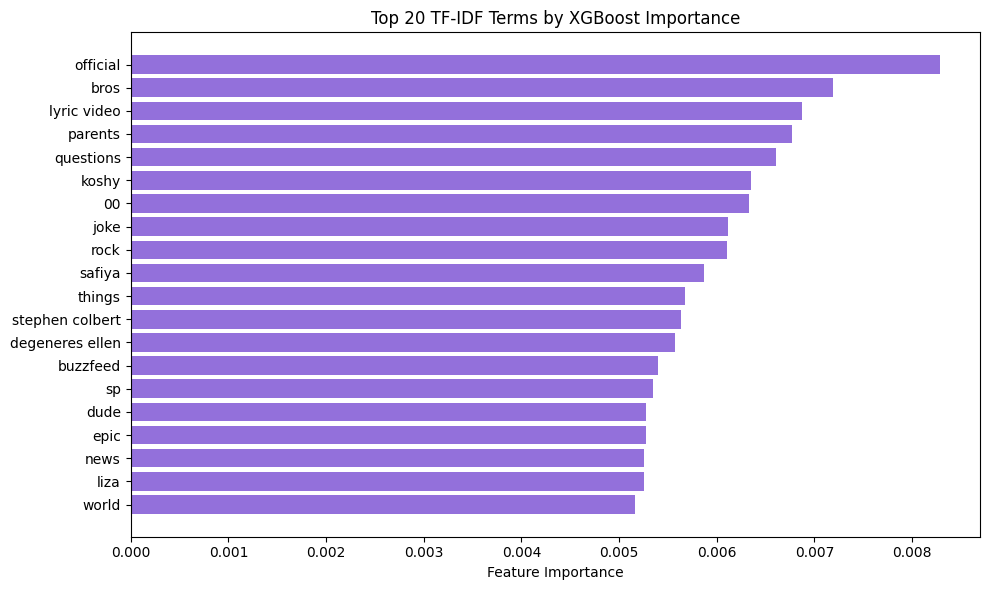

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from scipy.sparse import hstack, csr_matrix

# --- Prepare text ---
df_ml['title_clean'] = df_ml['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
df_ml['tags_clean']  = df_ml['tags'].str.replace('|', ' ').str.replace('"', '').str.lower()
df_ml['text_combined'] = df_ml['title_clean'] + ' ' + df_ml['tags_clean']

# Train/test split (same indices as classification)
train_idx = X_train_c.index
test_idx  = X_test_c.index

text_train = df_ml.loc[train_idx, 'text_combined']
text_test  = df_ml.loc[test_idx,  'text_combined']

# --- TF-IDF ---
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                         stop_words='english', min_df=3)
X_text_train = tfidf.fit_transform(text_train)
X_text_test  = tfidf.transform(text_test)

# --- Combine structured + text features ---
X_struct_train = csr_matrix(X_train_c.values)
X_struct_test  = csr_matrix(X_test_c.values)

X_combined_train = hstack([X_struct_train, X_text_train])
X_combined_test  = hstack([X_struct_test,  X_text_test])

print(f"Combined feature matrix: {X_combined_train.shape}")

# --- Train XGBoost on combined features ---
xgb_nlp = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='logloss', random_state=42, verbosity=0,
    tree_method='hist'
)
xgb_nlp.fit(X_combined_train, y_train_c)
y_prob_nlp = xgb_nlp.predict_proba(X_combined_test)[:, 1]
auc_nlp    = roc_auc_score(y_test_c, y_prob_nlp)

auc_baseline = roc_auc_score(y_test_c, xgb_clf.predict_proba(X_test_c)[:, 1])

print(f"\nXGBoost (structured only):    ROC-AUC = {auc_baseline:.4f}")
print(f"XGBoost (structured + TF-IDF): ROC-AUC = {auc_nlp:.4f}")
print(f"Improvement from NLP: +{(auc_nlp - auc_baseline):.4f}")

# --- Top TF-IDF terms by importance ---
tfidf_feature_names = np.array(tfidf.get_feature_names_out())
# For sparse XGBoost, get importances for TF-IDF portion
n_struct = len(CLF_FEATURES)
importances_all = xgb_nlp.feature_importances_
tfidf_importances = importances_all[n_struct:]
top_idx = np.argsort(tfidf_importances)[-20:][::-1]

plt.figure(figsize=(10, 6))
plt.barh(tfidf_feature_names[top_idx][::-1], tfidf_importances[top_idx][::-1],
         color='mediumpurple')
plt.xlabel('Feature Importance')
plt.title('Top 20 TF-IDF Terms by XGBoost Importance')
plt.tight_layout()
plt.show()

# ============================================================
# SECTION 8: SHAP — MODEL INTERPRETABILITY
# ============================================================

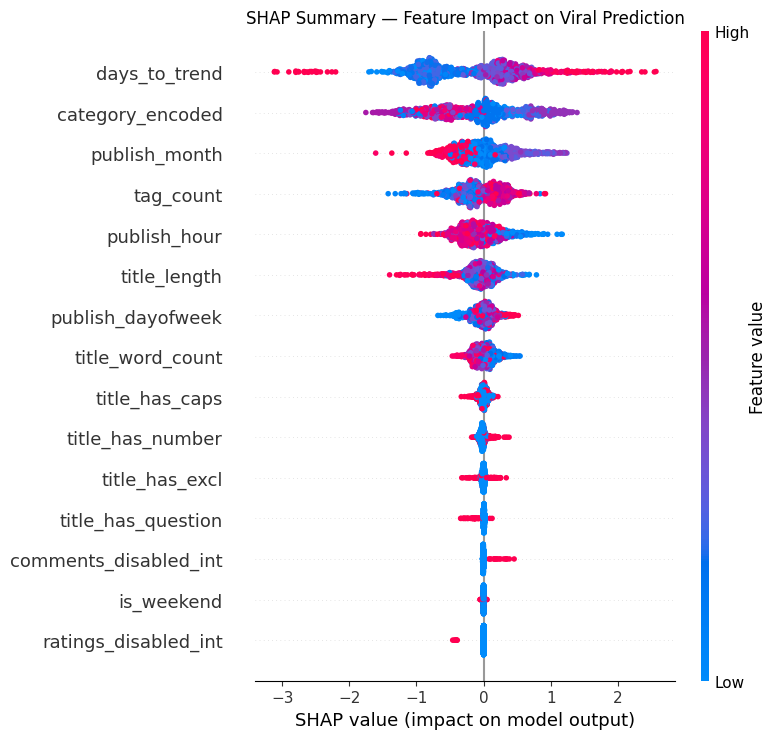

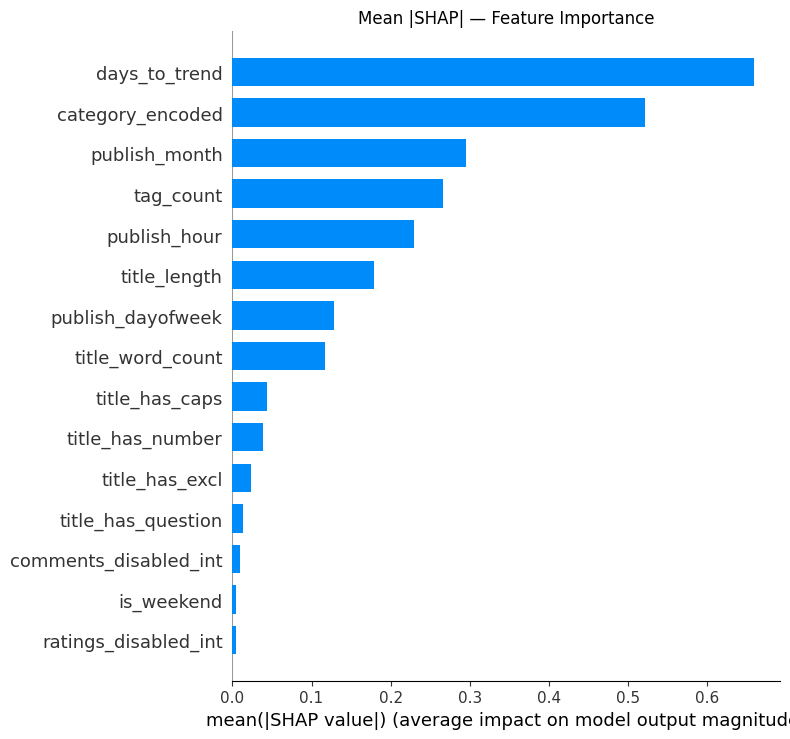

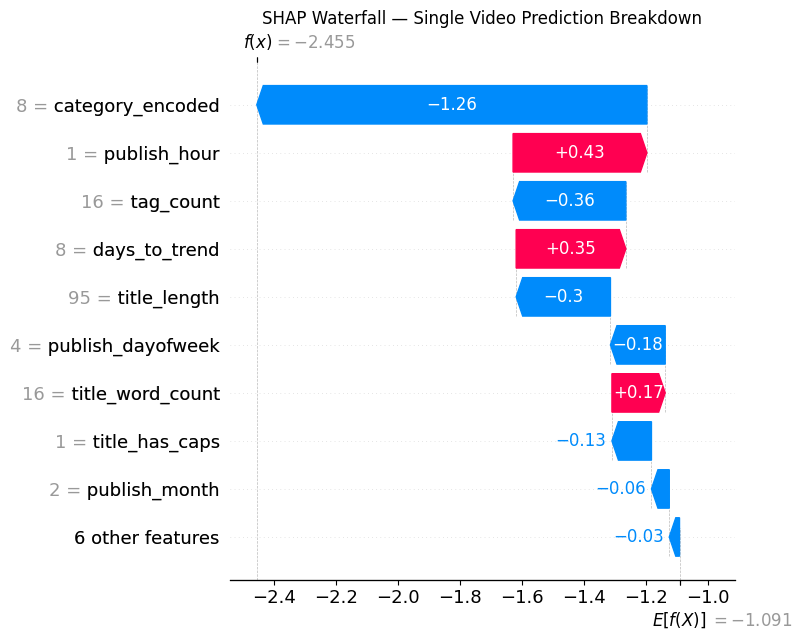

In [18]:
!pip install shap -q

import shap

# Use structured-features XGBoost (easier to label)
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_c)

# --- Summary plot (beeswarm) ---
plt.figure()
shap.summary_plot(shap_values, X_test_c, feature_names=CLF_FEATURES,
                  plot_type='dot', show=False)
plt.title('SHAP Summary — Feature Impact on Viral Prediction')
plt.tight_layout()
plt.show()

# --- Bar plot (mean |SHAP|) ---
plt.figure()
shap.summary_plot(shap_values, X_test_c, feature_names=CLF_FEATURES,
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| — Feature Importance')
plt.tight_layout()
plt.show()

# --- Waterfall for a single prediction ---
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_c.iloc[sample_idx].values,
        feature_names=CLF_FEATURES
    ),
    show=False
)
plt.title('SHAP Waterfall — Single Video Prediction Breakdown')
plt.tight_layout()
plt.show()